<a href="https://colab.research.google.com/github/natalia-maler/laptop_price_predictor/blob/main/laptop_price_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('laptop_data.csv')
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


Ten zbiór danych opisuje laptopy i ich cechy techniczne. Każdy wiersz to jeden model laptopa, a kolumny zawierają informacje,
które posłyżą do predykcji ceny (Price).

 Wyjaśnienie kolumn:
- Unnamed: 0: indeks/numer rekordu w zbiorze, liczba całkowita
- Company: producent laptopa, typ danych to kategoria
- TypeName: typ laptopa
- Inches: rozmiar ekranu w calach, liczba zmiennoprzecinkowa
- ScreenResolution: rozdzielczość i typ ekranu, tekst/kategoria
- Cpu: procesor, tekst
- Ram: ilość pamięci RAM, tekst
- Memory: typ i pojemność dysku, tekst
- Gpu: karta graficzna, tekst
- OpSys: system operacyjny, kategoria
- Weight: waga laptopa, tekst

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [ ]:
df.shape

(1303, 12)

In [ ]:
# usunięcie kolumny
df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [ ]:
df['Ram'] = df['Ram'].str.replace('GB','').astype(int)
df['Weight'] = df['Weight'].str.replace('kg','').astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int64  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
dtypes: float64(3), int64(1), object(7)
memory usage: 112.1+ KB


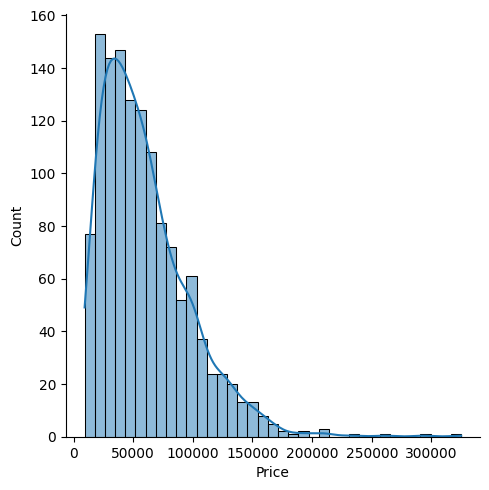

In [ ]:
import seaborn as sns
sns.displot(df['Price'], kde=True)

In [ ]:
df['Company'].value_counts()

,count
Company,
Dell,297
Lenovo,297
HP,274
Asus,158
Acer,103
MSI,54
Toshiba,48
Apple,21
Samsung,9


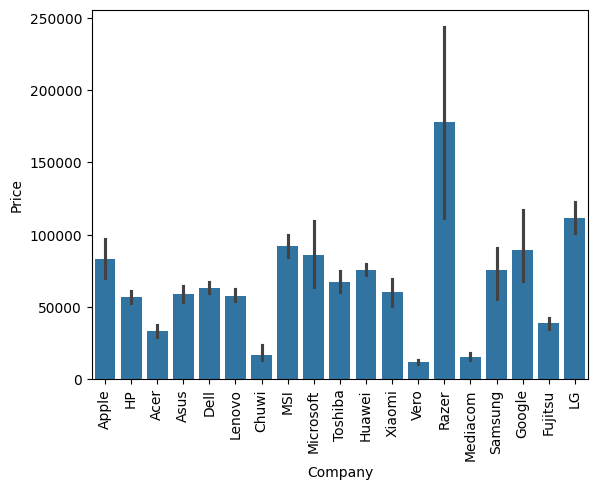

In [ ]:
sns.barplot(x=df['Company'], y =df['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
df['TypeName'].value_counts()

,count
TypeName,
Notebook,727
Gaming,205
Ultrabook,196
2 in 1 Convertible,121
Workstation,29
Netbook,25


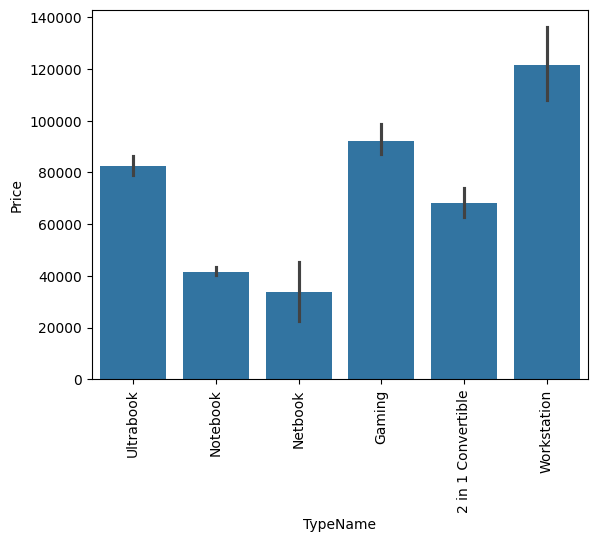

In [ ]:
sns.barplot(x=df['TypeName'], y =df['Price'])
plt.xticks(rotation='vertical')
plt.show()

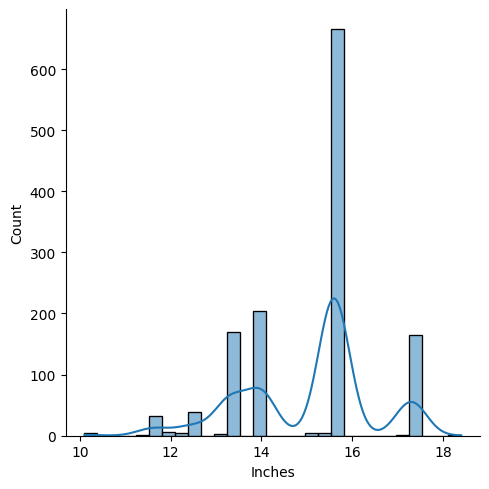

In [ ]:
# rozmiar ekranu
sns.displot(x=df['Inches'], kde=True)

<Axes: xlabel='Inches', ylabel='Price'>

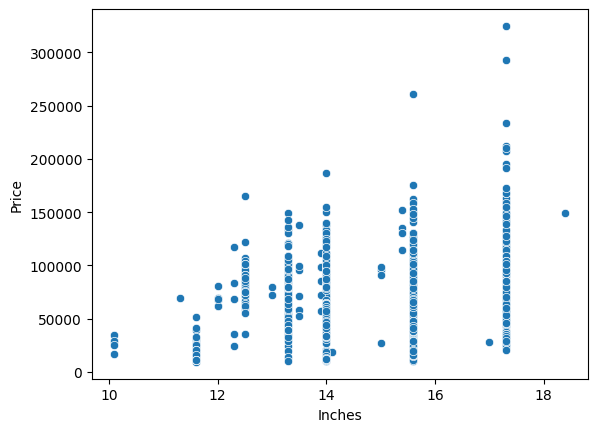

In [ ]:
sns.scatterplot(x=df['Inches'], y=df['Price'])

analiza ScreenResolution

In [ ]:
df['ScreenResolution'].value_counts()

,count
ScreenResolution,
Full HD 1920x1080,507
1366x768,281
IPS Panel Full HD 1920x1080,230
IPS Panel Full HD / Touchscreen 1920x1080,53
Full HD / Touchscreen 1920x1080,47
1600x900,23
Touchscreen 1366x768,16
Quad HD+ / Touchscreen 3200x1800,15
IPS Panel 4K Ultra HD 3840x2160,12


In [ ]:
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)

In [ ]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen
283,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,6,256GB SSD,Intel HD Graphics 620,Windows 10,2.20,30849.1200,0
393,MSI,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8,256GB SSD,Nvidia GeForce GTX 1050 Ti,Windows 10,2.70,71874.7200,0
614,Dell,Notebook,15.6,1366x768,Intel Core i5 7300U 2.6GHz,4,500GB HDD,Intel HD Graphics 620,Linux,1.93,46300.3200,0
567,Fujitsu,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,8,1TB HDD,Intel HD Graphics 620,Windows 10,2.20,39373.9200,0
1267,Dell,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8,1TB HDD,AMD Radeon R5 M430,Linux,2.30,42943.1472,0


In [ ]:
df['Touchscreen'].value_counts()

,count
Touchscreen,
0,1111
1,192


<Axes: xlabel='Touchscreen', ylabel='Price'>

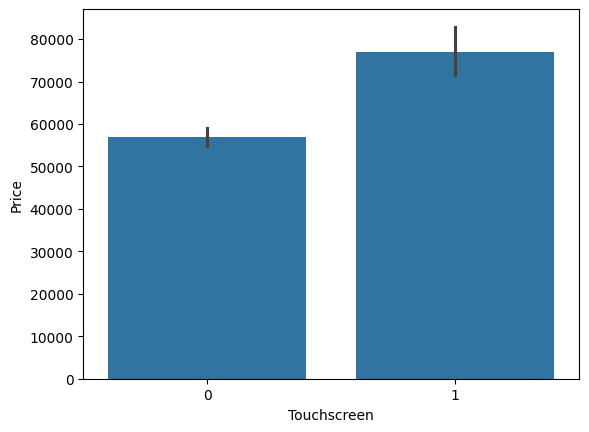

In [ ]:
sns.barplot(x=df['Touchscreen'], y=df['Price'])

In [ ]:
df['Ips'] = df['ScreenResolution'].apply(lambda x: 1 if 'IPS' in x else 0)

In [ ]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1


analiza Ips

In [ ]:
df['Ips'].value_counts()

,count
Ips,
0,938
1,365


<Axes: xlabel='Ips', ylabel='Price'>

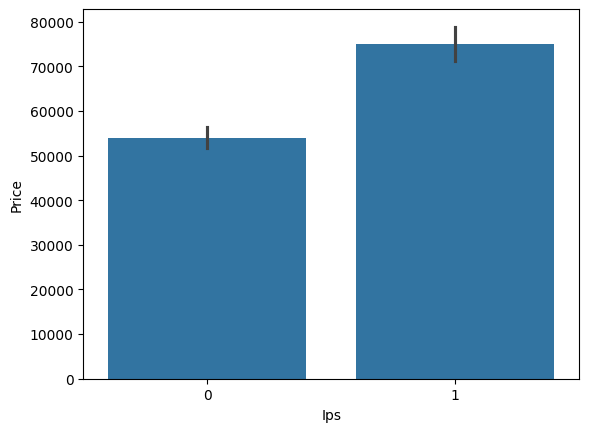

In [ ]:
sns.barplot(x=df['Ips'], y=df['Price'])

In [ ]:
df['X_res'] = df['ScreenResolution'].str.extract(r'(\d+)x')[0].astype(int)
df['Y_res'] = df['ScreenResolution'].str.extract(r'x(\d+)')[0].astype(int)

In [ ]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int64  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
 11  Touchscreen       1303 non-null   int64  
 12  Ips               1303 non-null   int64  
 13  X_res             1303 non-null   int64  
 14  Y_res             1303 non-null   int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 152.8+ KB


In [ ]:
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

,Price
Price,1.000000
Ram,0.743007
X_res,0.556529
Y_res,0.552809
Ips,0.252208
Weight,0.210370
Touchscreen,0.191226
Inches,0.068197


Wnioski korelacji
- Ram -> 0.743 -  To bardzo wysoka korelacja. Oznacza im więcej RAM-u, tym zwykle wyższa cena laptopa.
- X_res i Y_res: 0.556 i 0.553 - Średnio silna zależność. Czyli wyższa rozdzielczość - droższy laptop.

## PPI(Pixels Per Inch), czyli ile pikseli przypada na 1 cal ekranu.



In [ ]:
df['ppi'] = (((df['X_res']**2) + (df['Y_res']**2))**0.5 / df['Inches']).astype('float')

In [ ]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,X_res,Y_res,ppi
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,226.983005
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,127.677940
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,141.211998
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,220.534624
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,226.983005


In [ ]:
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

,Price
Price,1.000000
Ram,0.743007
X_res,0.556529
Y_res,0.552809
ppi,0.473487
Ips,0.252208
Weight,0.210370
Touchscreen,0.191226
Inches,0.068197


In [ ]:
# usunięcie już niepotrzebnych kolumn
df.drop(columns=['ScreenResolution','Inches','X_res','Y_res'], inplace=True)

In [ ]:
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005


Analiza CPU

In [ ]:
df['Cpu'].value_counts()

,count
Cpu,
Intel Core i5 7200U 2.5GHz,190
Intel Core i7 7700HQ 2.8GHz,146
Intel Core i7 7500U 2.7GHz,134
Intel Core i7 8550U 1.8GHz,73
Intel Core i5 8250U 1.6GHz,72
...,...
Intel Core i5 7200U 2.70GHz,1
Intel Core M M7-6Y75 1.2GHz,1
Intel Core M 6Y54 1.1GHz,1


In [ ]:
df['Cpu'].apply(lambda x: x.split())

,Cpu
0,"[Intel, Core, i5, 2.3GHz]"
1,"[Intel, Core, i5, 1.8GHz]"
2,"[Intel, Core, i5, 7200U, 2.5GHz]"
3,"[Intel, Core, i7, 2.7GHz]"
4,"[Intel, Core, i5, 3.1GHz]"
...,...
1298,"[Intel, Core, i7, 6500U, 2.5GHz]"
1299,"[Intel, Core, i7, 6500U, 2.5GHz]"
1300,"[Intel, Celeron, Dual, Core, N3050, 1.6GHz]"
1301,"[Intel, Core, i7, 6500U, 2.5GHz]"


In [ ]:
df['Cpu_Name'] = df['Cpu'].apply(lambda x: " ".join(x.split()[0:3]))

In [ ]:
df.head(10)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu_Name
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5
5,Acer,Notebook,AMD A9-Series 9420 3GHz,4,500GB HDD,AMD Radeon R5,Windows 10,2.10,21312.0000,0,0,100.454670,AMD A9-Series 9420
6,Apple,Ultrabook,Intel Core i7 2.2GHz,16,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04,114017.6016,0,1,220.534624,Intel Core i7
7,Apple,Ultrabook,Intel Core i5 1.8GHz,8,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,61735.5360,0,0,127.677940,Intel Core i5
8,Asus,Ultrabook,Intel Core i7 8550U 1.8GHz,16,512GB SSD,Nvidia GeForce MX150,Windows 10,1.30,79653.6000,0,0,157.350512,Intel Core i7
9,Acer,Ultrabook,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,Windows 10,1.60,41025.6000,0,1,157.350512,Intel Core i5


In [ ]:
def fetch_processor(text):
    if text == 'Intel Core i7' or text == 'Intel Core i5' or text == 'Intel Core i3':
        return text
    else:
        if text.split()[0] == 'Intel':
            return 'Other Intel Processor'
        else:
            return 'AMD Processor'

In [ ]:
df['Cpu_brand'] = df['Cpu_Name'].apply(fetch_processor)

In [ ]:
df.head(10)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu_Name,Cpu_brand
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,Intel Core i5
5,Acer,Notebook,AMD A9-Series 9420 3GHz,4,500GB HDD,AMD Radeon R5,Windows 10,2.10,21312.0000,0,0,100.454670,AMD A9-Series 9420,AMD Processor
6,Apple,Ultrabook,Intel Core i7 2.2GHz,16,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04,114017.6016,0,1,220.534624,Intel Core i7,Intel Core i7
7,Apple,Ultrabook,Intel Core i5 1.8GHz,8,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,61735.5360,0,0,127.677940,Intel Core i5,Intel Core i5
8,Asus,Ultrabook,Intel Core i7 8550U 1.8GHz,16,512GB SSD,Nvidia GeForce MX150,Windows 10,1.30,79653.6000,0,0,157.350512,Intel Core i7,Intel Core i7
9,Acer,Ultrabook,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,Windows 10,1.60,41025.6000,0,1,157.350512,Intel Core i5,Intel Core i5


In [ ]:
df['Cpu_brand'].value_counts()

,count
Cpu_brand,
Intel Core i7,527
Intel Core i5,423
Other Intel Processor,154
Intel Core i3,136
AMD Processor,63


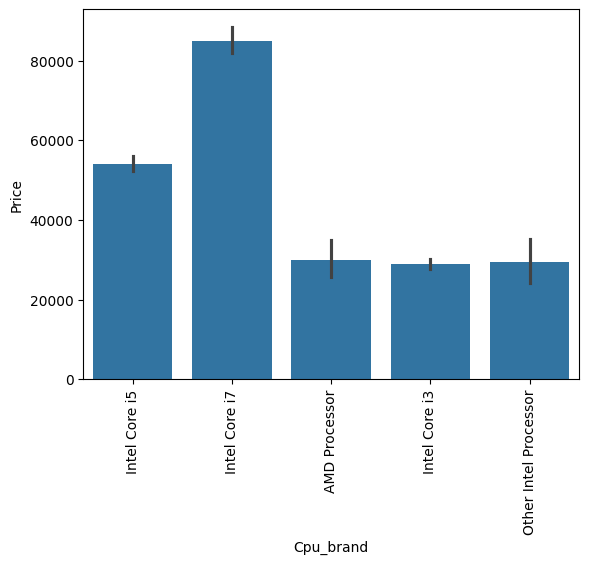

In [ ]:
sns.barplot(x=df['Cpu_brand'], y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
df.drop(columns=['Cpu', 'Cpu_Name'], inplace=True)

In [ ]:
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu_brand
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5


analiza Ram

In [ ]:
df['Ram'].value_counts()

,count
Ram,
8,619
4,375
16,200
6,41
12,25
2,22
32,17
24,3
64,1


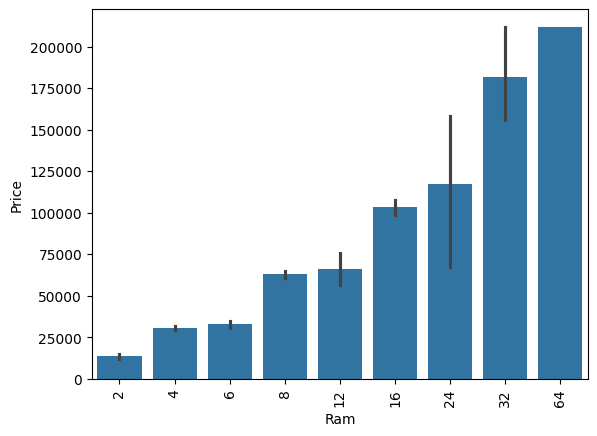

In [ ]:
sns.barplot(x=df['Ram'], y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

analiza Memory

In [ ]:
df['Memory'].value_counts()

,count
Memory,
256GB SSD,412
1TB HDD,223
500GB HDD,132
512GB SSD,118
128GB SSD + 1TB HDD,94
128GB SSD,76
256GB SSD + 1TB HDD,73
32GB Flash Storage,38
2TB HDD,16


In [ ]:
# feature engineering dla kolumny Memory
df['Memory'] = df['Memory'].astype(str).replace('\\.0', '', regex=True)
df['Memory'] = df['Memory'].str.replace('GB', '', regex=True)
df['Memory'] = df['Memory'].str.replace('TB', '000', regex=True)
new = df['Memory'].str.split("+", n = 1, expand = True)

df['first'] = new[0]
df['first'] = df['first'].str.strip()

df['second'] = new[1]

df['Layer1HDD'] = df['first'].apply(lambda x: 1 if 'HDD' in x else 0)
df['Layer1SSD'] = df['first'].apply(lambda x: 1 if 'SSD' in x else 0)
df['Layer1Hybrid'] = df['first'].apply(lambda x: 1 if 'Hybrid' in x else 0)
df['Layer1Flash_Storage'] = df['first'].apply(lambda x: 1 if 'Flash Storage' in x else 0)

df['first'] = df['first'].str.replace(r'\D','', regex=True)

df['second'].fillna('0',inplace=True)

df['Layer2HDD'] = df['second'].apply(lambda x: 1 if 'HDD' in x else 0)
df['Layer2SSD'] = df['second'].apply(lambda x: 1 if 'SSD' in x else 0)
df['Layer2Hybrid'] = df['second'].apply(lambda x: 1 if 'Hybrid' in x else 0)
df['Layer2Flash_Storage'] = df['second'].apply(lambda x: 1 if 'Flash Storage' in x else 0)

df['second'] = df['second'].str.replace(r'\D','', regex=True)

df['first'] = df['first'].astype(int)
df['second'] = df['second'].astype(int)

df['HDD'] = (df['first'] * df['Layer1HDD']) + (df['second'] * df['Layer2HDD'])
df['SSD'] = (df['first'] * df['Layer1SSD']) + (df['second'] * df['Layer2SSD'])
df['Hybrid'] = (df['first'] * df['Layer1Hybrid']) + (df['second'] * df['Layer2Hybrid'])
df['Flash_Storage'] = (df['first'] * df['Layer1Flash_Storage']) + (df['second'] * df['Layer2Flash_Storage'])

df.drop(columns=['first','second','Layer1HDD','Layer1SSD','Layer1Hybrid', 'Layer1Flash_Storage','Layer2HDD','Layer2SSD','Layer2Hybrid','Layer2Flash_Storage'],inplace=True)

/tmp/ipykernel_5378/3403615269.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['second'].fillna('0',inplace=True)


Wyjasnienie kodu powyżej
- Celem jest zamiana trudnego tekstu typu: '256GB SSD', '1TB HDD', '128GB SSD + 1TB HDD' na osobne liczbowe kolumny: HDD, SSD, Hybrid, Flash_storage

In [ ]:
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,0,0
1,Apple,Ultrabook,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,0,128
2,HP,Notebook,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,0,0
3,Apple,Ultrabook,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,0,0
4,Apple,Ultrabook,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,0,0


In [ ]:
df.drop(columns=['Memory'], inplace=True)

In [ ]:
df.head(10)

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,0,0
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,0,128
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,0,0
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,0,0
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,0,0
5,Acer,Notebook,4,AMD Radeon R5,Windows 10,2.10,21312.0000,0,0,100.454670,AMD Processor,500,0,0,0
6,Apple,Ultrabook,16,Intel Iris Pro Graphics,Mac OS X,2.04,114017.6016,0,1,220.534624,Intel Core i7,0,0,0,256
7,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,61735.5360,0,0,127.677940,Intel Core i5,0,0,0,256
8,Asus,Ultrabook,16,Nvidia GeForce MX150,Windows 10,1.30,79653.6000,0,0,157.350512,Intel Core i7,0,512,0,0
9,Acer,Ultrabook,8,Intel UHD Graphics 620,Windows 10,1.60,41025.6000,0,1,157.350512,Intel Core i5,0,256,0,0


In [ ]:
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

,Price
Price,1.000000
Ram,0.743007
SSD,0.670799
ppi,0.473487
Ips,0.252208
Weight,0.210370
Touchscreen,0.191226
Hybrid,0.007989
Flash_Storage,-0.040511
HDD,-0.096441


In [ ]:
#usunięcie kolumn mniej 'znaczących'
df.drop(columns=['Hybrid','Flash_Storage'], inplace=True)

In [ ]:
df.head()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256


analiza Gpu

In [ ]:
df['Gpu'].value_counts()

,count
Gpu,
Intel HD Graphics 620,281
Intel HD Graphics 520,185
Intel UHD Graphics 620,68
Nvidia GeForce GTX 1050,66
Nvidia GeForce GTX 1060,48
...,...
Nvidia Quadro M500M,1
AMD Radeon R7 M360,1
Nvidia Quadro M3000M,1


In [ ]:
df['Gpu_brand'] = df['Gpu'].apply(lambda x: x.split()[0])

In [ ]:
df.head()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Gpu_brand
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel


In [ ]:
df['Gpu_brand'].value_counts()

,count
Gpu_brand,
Intel,722
Nvidia,400
AMD,180
ARM,1


In [ ]:
df = df[df['Gpu_brand'] != 'ARM']

In [ ]:
df['Gpu_brand'].value_counts()

,count
Gpu_brand,
Intel,722
Nvidia,400
AMD,180


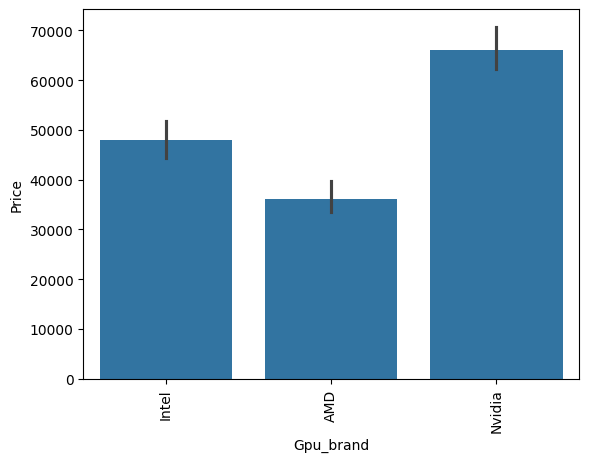

In [ ]:
sns.barplot(x=df['Gpu_brand'], y=df['Price'],estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
df.drop(columns=['Gpu'], inplace=True)

In [ ]:
df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Gpu_brand
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel


analiza systemu operacyjnego

In [ ]:
df['OpSys'].value_counts()

,count
OpSys,
Windows 10,1072
No OS,66
Linux,62
Windows 7,45
Chrome OS,26
macOS,13
Mac OS X,8
Windows 10 S,8
Android,2


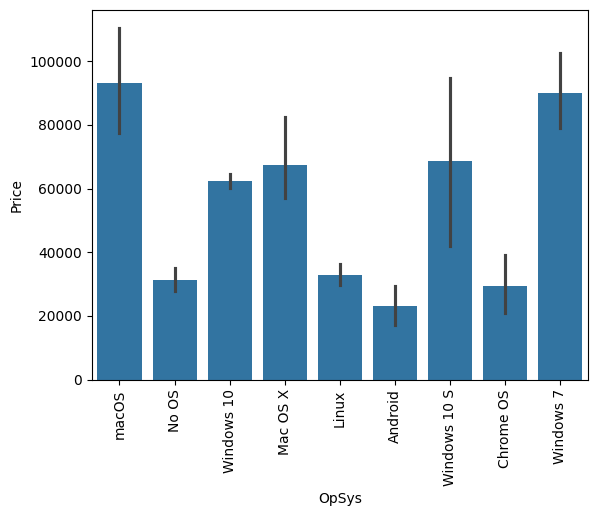

In [ ]:
sns.barplot(x=df['OpSys'], y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
def category_os(sys):
  if sys == 'Windows 10' or sys == 'Windows 7' or sys == 'Windows 10 S':
    return 'Windows'
  elif sys == 'macOS' or sys == 'Mac OS X':
    return 'Mac'
  else:
    return 'Others/No OS/Linux'

In [ ]:
df['os'] = df['OpSys'].apply(category_os)

In [ ]:
df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Gpu_brand,os
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


In [ ]:
df.drop(columns=['OpSys'], inplace=True)

In [ ]:
df.head()

,Company,TypeName,Ram,Weight,Price,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Gpu_brand,os
0,Apple,Ultrabook,8,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


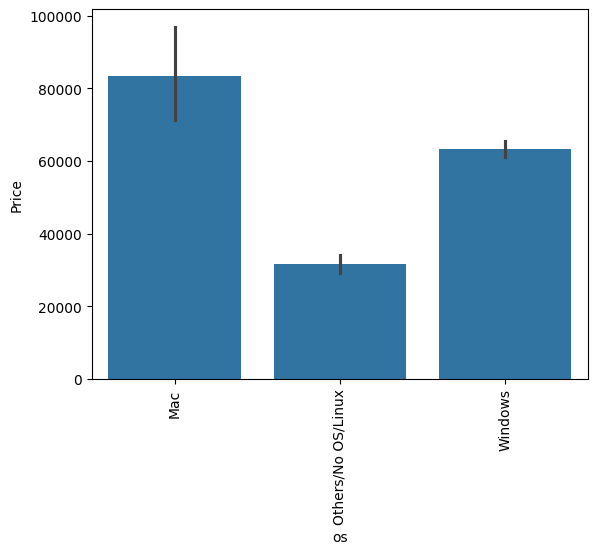

In [ ]:
sns.barplot(x=df['os'], y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

analiza weight

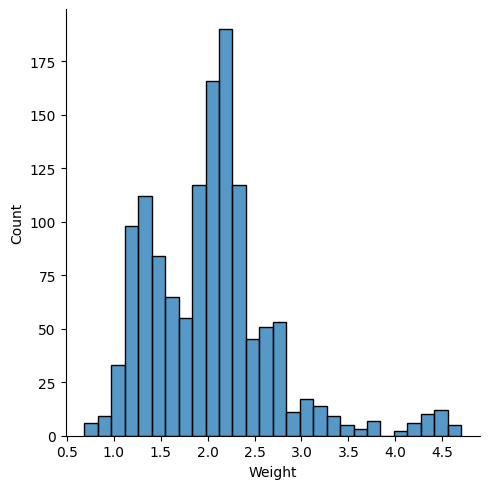

In [ ]:
sns.displot(df['Weight'])

<Axes: xlabel='Weight', ylabel='Price'>

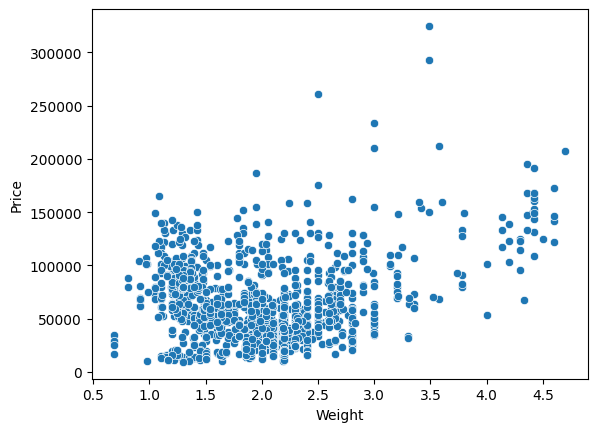

In [ ]:
sns.scatterplot(x=df['Weight'], y=df['Price'])

<Axes: >

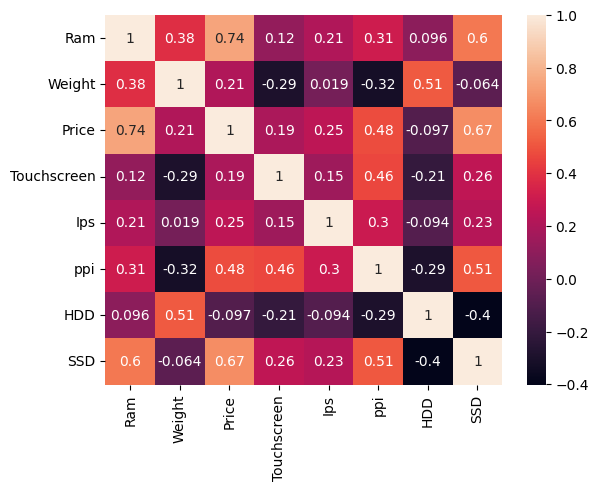

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

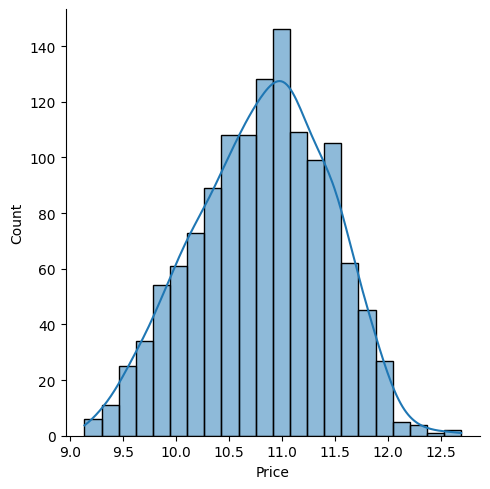

In [ ]:
sns.displot(np.log(df['Price']), kde=True)

In [ ]:
X = df.drop(columns=['Price'])
y = np.log(df['Price'])

In [ ]:
X

,Company,TypeName,Ram,Weight,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Gpu_brand,os
0,Apple,Ultrabook,8,1.37,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,0,0,141.211998,Intel Core i5,0,256,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16,1.83,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,0,1,226.983005,Intel Core i5,0,256,Intel,Mac
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,1.80,1,1,157.350512,Intel Core i7,0,128,Intel,Windows
1299,Lenovo,2 in 1 Convertible,16,1.30,1,1,276.053530,Intel Core i7,0,512,Intel,Windows
1300,Lenovo,Notebook,2,1.50,0,0,111.935204,Other Intel Processor,0,0,Intel,Windows
1301,HP,Notebook,6,2.19,0,0,100.454670,Intel Core i7,1000,0,AMD,Windows


In [ ]:
y

,Price
0,11.175755
1,10.776777
2,10.329931
3,11.814476
4,11.473101
...,...
1298,10.433899
1299,11.288115
1300,9.409283
1301,10.614129


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [ ]:
X_train

,Company,TypeName,Ram,Weight,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Gpu_brand,os
147,Asus,Notebook,4,2.00,0,0,141.211998,Other Intel Processor,1000,0,Intel,Windows
342,HP,Notebook,8,2.10,0,1,141.211998,Intel Core i3,1000,0,Nvidia,Windows
1003,HP,Notebook,4,1.64,0,0,111.935204,Intel Core i5,500,0,Intel,Windows
814,Dell,Notebook,8,2.18,0,0,141.211998,Intel Core i5,0,256,AMD,Windows
344,Dell,Ultrabook,8,1.20,0,0,165.632118,Intel Core i7,0,256,Intel,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...
1095,Acer,Notebook,8,2.40,0,0,141.211998,Intel Core i5,1000,256,Nvidia,Windows
1130,HP,Notebook,8,2.04,0,0,100.454670,Intel Core i7,2000,0,Intel,Windows
1295,Dell,Notebook,8,2.30,0,0,100.454670,Intel Core i7,1000,0,AMD,Others/No OS/Linux
860,Lenovo,Notebook,8,2.30,0,1,141.211998,Intel Core i5,1000,0,Intel,Windows


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

LinearRegression

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('column_tnf', OneHotEncoder(sparse_output=False, drop='first'), [0,1,7,10,11])
], remainder='passthrough')

lr_model = LinearRegression()

pipe = Pipeline([
     ('preprocessing', preprocessor),
    ('linear_regression', lr_model)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

print('R2 score', r2_score(y_test, y_pred))
print('MAE', mean_absolute_error(y_test, y_pred))

R2 score 0.8081332010693885
MAE 0.2146135430377646


In [ ]:
# Porównanie prawdziwych i przewidywanych wartości
comparison = pd.DataFrame({

    'Actual Price': np.exp(y_test),
    'Predicted Price': np.exp(y_pred)

})

comparison['Difference'] = (comparison['Actual Price']- comparison['Predicted Price'])
comparison['Error %'] = (abs(comparison['Difference'])/ comparison['Actual Price']) * 100
comparison.head(10)

,Actual Price,Predicted Price,Difference,Error %
478,35964.0000,42076.792403,-6112.792403,16.996976
724,71847.0144,69973.405995,1873.608405,2.607775
312,111834.7200,102079.086289,9755.633711,8.723260
851,101178.7200,72858.142723,28320.577277,27.990646
1276,24455.5200,29438.265174,-4982.745174,20.374726
115,74538.1872,66995.969538,7542.217662,10.118596
816,95850.7200,177101.981041,-81251.261041,84.768545
722,79866.7200,68463.059365,11403.660635,14.278364
1142,86793.1200,64714.862722,22078.257278,25.437797
101,18594.7200,26790.333549,-8195.613549,44.074950


In [ ]:
X_train

,Company,TypeName,Ram,Weight,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Gpu_brand,os
147,Asus,Notebook,4,2.00,0,0,141.211998,Other Intel Processor,1000,0,Intel,Windows
342,HP,Notebook,8,2.10,0,1,141.211998,Intel Core i3,1000,0,Nvidia,Windows
1003,HP,Notebook,4,1.64,0,0,111.935204,Intel Core i5,500,0,Intel,Windows
814,Dell,Notebook,8,2.18,0,0,141.211998,Intel Core i5,0,256,AMD,Windows
344,Dell,Ultrabook,8,1.20,0,0,165.632118,Intel Core i7,0,256,Intel,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...
1095,Acer,Notebook,8,2.40,0,0,141.211998,Intel Core i5,1000,256,Nvidia,Windows
1130,HP,Notebook,8,2.04,0,0,100.454670,Intel Core i7,2000,0,Intel,Windows
1295,Dell,Notebook,8,2.30,0,0,100.454670,Intel Core i7,1000,0,AMD,Others/No OS/Linux
860,Lenovo,Notebook,8,2.30,0,1,141.211998,Intel Core i5,1000,0,Intel,Windows


Ridge Regression

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
],remainder='passthrough')

rr_model = Ridge(alpha=10)

pipe = Pipeline([
    ('preprocessins',preprocessor),
    ('ridge_regression',rr_model)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8014893505385322
MAE 0.21965719392405994


Lasso Regression

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
],remainder='passthrough')

lasso_model = Lasso(alpha=0.001)

pipe = Pipeline([
    ('preprocessing',preprocessor),
    ('lasso_regression',lasso_model)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8056423346675294
MAE 0.21696654982393493


KNN

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
],remainder='passthrough')

knn_model = KNeighborsRegressor(n_neighbors=3)

pipe = Pipeline([
    ('spreprocessing',preprocessor),
    ('KNN',knn_model)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.7633107429142074
MAE 0.22739753799105092


Decision Tree

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
],remainder='passthrough')

dt_model = DecisionTreeRegressor(max_depth=8)

pipe = Pipeline([
    ('spreprocessing',preprocessor),
    ('decision_tree',dt_model)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8321529588818978
MAE 0.1944395099675216


SVM

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
],remainder='passthrough')

svm_model = SVR(kernel='rbf',C=10000,epsilon=0.1)

pipe = Pipeline([
    ('preprocessing',preprocessor),
    ('svm',svm_model)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8237723643117905
MAE 0.19618574021293694


Random Forest

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
],remainder='passthrough')

rf_model = RandomForestRegressor(n_estimators=100,
                              random_state=3,
                              max_samples=0.5,
                              max_features=0.75,
                              max_depth=15)

pipe = Pipeline([
    ('preprocessing',preprocessor),
    ('random_forest',rf_model)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8612552202433235
MAE 0.176266780841514


ExtraTrees

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
],remainder='passthrough')

etr_model = ExtraTreesRegressor(n_estimators=100,
                              random_state=3,
                              max_samples=0.5,
                              max_features=0.75,
                              max_depth=15,
                              bootstrap=True)

pipe = Pipeline([
    ('preprocessing',preprocessor),
    ('extraTrees',etr_model)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8588217418615298
MAE 0.17669066104836534


AdaBoost

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
],remainder='passthrough')

ab_model = AdaBoostRegressor(n_estimators=15,learning_rate=1.0)

pipe = Pipeline([
    ('preprocessing',preprocessor),
    ('AdaBoost',ab_model)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.7623788980051369
MAE 0.25085508143707547


Gradient Boost

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
],remainder='passthrough')

gb_model = GradientBoostingRegressor(n_estimators=500)

pipe = Pipeline([
    ('preprocessing',preprocessor),
    ('Gradient_boost',gb_model)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8734258219820753
MAE 0.1669001198562859


XgBoost

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
],remainder='passthrough')

xgb_model = XGBRegressor(n_estimators=45,max_depth=5,learning_rate=0.5)

pipe = Pipeline([
    ('preprocessing',preprocessor),
    ('XgBoost',xgb_model)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8816078076945755
MAE 0.16219935986023093


In [ ]:
comparison = pd.DataFrame({

    'Actual Price': np.exp(y_test),
    'Predicted Price': np.exp(y_pred)

})
comparison['Difference'] = (
    comparison['Actual Price'] - comparison['Predicted Price']
)

comparison['Error %'] = (
    abs(comparison['Difference']) / comparison['Actual Price']) * 100
comparison.head(10)

,Actual Price,Predicted Price,Difference,Error %
478,35964.0000,37369.398438,-1405.398437,3.907792
724,71847.0144,70969.117188,877.897213,1.221898
312,111834.7200,87507.468750,24327.251250,21.752861
851,101178.7200,94908.406250,6270.313750,6.197265
1276,24455.5200,24515.980469,-60.460469,0.247226
115,74538.1872,70640.539062,3897.648138,5.229062
816,95850.7200,99948.953125,-4098.233125,4.275641
722,79866.7200,87975.054688,-8108.334687,10.152332
1142,86793.1200,80440.640625,6352.479375,7.319105
101,18594.7200,26113.480469,-7518.760469,40.434922


In [ ]:
# przykład predykcji nowego laptopa
new_laptop = pd.DataFrame({
    'Company': ['Dell'],
    'TypeName': ['Gaming'],
    'Ram': [16],
    'Weight': [2.3],
    'Touchscreen': [0],
    'Ips': [1],
    'ppi': [141],
    'Cpu_brand': ['Intel Core i7'],
    'HDD': [0],
    'SSD': [512],
    'Gpu_brand': ['Nvidia'],
    'os': ['Windows']

})

predicted_price = np.exp(pipe.predict(new_laptop)[0])
print("Przewidywana cena:", predicted_price)

Przewidywana cena: 89558.91


Exporting the Model

In [ ]:
import pickle

pickle.dump(df,open('df.pkl','wb'))
pickle.dump(pipe,open('pipe.pkl','wb'))

Porównanie

In [ ]:
models = {

    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=10),
    'Lasso': Lasso(alpha=0.001),
    'KNN': KNeighborsRegressor(n_neighbors=3),
    'Decision Tree': DecisionTreeRegressor(max_depth=8),
    'SVR': SVR(kernel='rbf', C=10000, epsilon=0.1),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=3,
        max_samples=0.5,
        max_features=0.75,
        max_depth=15
    ),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=100,
        random_state=3,
        max_samples=0.5,
        max_features=0.75,
        max_depth=15,
        bootstrap=True
    ),
    'AdaBoost': AdaBoostRegressor(
        n_estimators=15,
        learning_rate=1.0
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=500
    ),
    'XGBoost': XGBRegressor(
        n_estimators=45,
        max_depth=5,
        learning_rate=0.5
    )
}

In [ ]:
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(sparse_output=False, drop='first'), [0,1,7,10,11])], remainder='passthrough')

In [ ]:
results = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    mae = mean_absolute_error(y_test, y_pred)

    results.append([name, r2, mae])

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=['Model', 'R2 Score', 'MAE']
)
results_df.sort_values(by='R2 Score', ascending=False)

,Model,R2 Score,MAE
10,XGBoost,0.881608,0.162199
9,Gradient Boosting,0.874361,0.166342
6,Random Forest,0.861255,0.176267
7,Extra Trees,0.858822,0.176691
4,Decision Tree,0.832681,0.194100
5,SVR,0.823772,0.196186
0,Linear Regression,0.808133,0.214614
2,Lasso,0.805642,0.216967
1,Ridge,0.801489,0.219657
3,KNN,0.763311,0.227398


## Podsumowanie
-  XGBoost ma najwyższe R^2 = 0.8816, MAE = 0.1622. To znaczy, że model wyjaśnia około 88% zmienności cen laptopów. Oznacza, że model dobrze nauczył się zależności między: RAM, SSD, PPI, GPU brand, CPU, typem laptopa, systemem operacyjnym
a ceną. XGBoost wygrał, bo świetnie radzi sobie z nieliniowościami np. wzrost ceny nie jest liniowy: 8 -> 16 GB RAM = duży skok, 16 -> 32 GB = jeszcze większy
- Gradient Boosting prawie wygrał, czyli klasyczny boosting też działa świetnie.
- Random Forest i Extra Trees, bardzo solidne, oba odporne, mocne.

In [ ]:
new_laptop = pd.DataFrame({

    'Company': ['Dell'],
    'TypeName': ['Gaming'],
    'Ram': [16],
    'Weight': [2.3],
    'Touchscreen': [0],
    'Ips': [1],
    'ppi': [141],
    'Cpu_brand': ['Intel Core i7'],
    'HDD': [0],
    'SSD': [512],
    'Gpu_brand': ['Nvidia'],
    'os': ['Windows']

})

In [ ]:
# porównianie nowego produktu dla wszystkich modeli

predictions_price = []

for name, model in models.items():

    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])


    pipe.fit(X_train, y_train)

    pred = np.exp(pipe.predict(new_laptop)[0])

    predictions_price.append([name, pred])

In [ ]:
predictions_price_df = pd.DataFrame(predictions_price,columns=['Model', 'Predicted Price'])
predictions_price_df.sort_values(by='Predicted Price',ascending=False)

,Model,Predicted Price
1,Ridge,107017.251895
0,Linear Regression,105860.796720
2,Lasso,104720.257507
8,AdaBoost,99518.635721
9,Gradient Boosting,96948.004584
4,Decision Tree,94144.999099
10,XGBoost,89558.906250
7,Extra Trees,85348.468554
6,Random Forest,84649.729553
5,SVR,84266.962935


Zakres predykcji dla najlepszych modeli

In [ ]:
top_models = {
    'XGBoost': XGBRegressor(
        n_estimators=45,
        max_depth=5,
        learning_rate=0.5
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=500
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=3,
        max_samples=0.5,
        max_features=0.75,
        max_depth=15
    ),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=100,
        random_state=3,
        max_samples=0.5,
        max_features=0.75,
        max_depth=15,
        bootstrap=True
    )
}

In [ ]:
prices = []

for name, model in top_models.items():

    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    pred = np.exp(pipe.predict(new_laptop)[0])

    min_range = pred * 0.9
    max_range = pred * 1.1

    prices.append([
        name,
        pred,
        min_range,
        max_range
    ])


predictions_df = pd.DataFrame(

    prices,

    columns=[

        'Model',
        'Predicted Price',
        'Min Range',
        'Max Range'
    ])

predictions_df.sort_values(by='Predicted Price', ascending=False)

,Model,Predicted Price,Min Range,Max Range
1,Gradient Boosting,96948.004584,87253.204126,106642.805042
0,XGBoost,89558.906250,80603.015625,98514.796875
3,Extra Trees,85348.468554,76813.621698,93883.315409
2,Random Forest,84649.729553,76184.756598,93114.702508


Podsumowanie wyników predykcji
- Najlepsze modele przewidziały cenę nowego laptopa w stosunkowo podobnym zakresie od około 84k do 97k.
- Modele oparte na drzewach decyzyjnych wykazały dość dużą spójność predykcji, co sugeruje stabilną estymację wartości laptopa.
Najbardziej konserwatywne predykcje wygenerowały Random Forest i Extra Trees, natomiast najwyższą wycenę przewidział Gradient Boosting.
Na podstawie wszystkich modeli można przyjąć, że realistyczna cena badanego laptopa znajduje się w przedziale: 85 000 - 97 000.
- Uwzględnienie zakresu predykcji pozwala lepiej interpretować niepewność modeli machine learning i bardziej realistycznie szacować wartość rynkową produktu.